# NCP Contact Demo

This notebook showcases the new NCP backend in `solve_nivp.ncp_contact`.

It focuses on three questions:

1. Can Fischer-Burmeister NCP carry a short impact / rebound example?
2. Can the same backend show the onset of Coulomb sliding in a frictional problem?
3. Does the augmented NCP system run through the core implicit integrators?

For apples-to-apples comparisons, everything below uses fixed-step implicit solves with `adaptive=False`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import solve_nivp
from solve_nivp import build_dynamic_ncp_contact

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)


def run_case(cs, *, method="backward_euler", t_span=(0.0, 1.0), h=0.005, max_iter=80):
    t, y, h_hist, fk, info = solve_nivp.solve_nivp(
        fun=cs.rhs,
        t_span=t_span,
        y0=cs.y0,
        method=method,
        projection=cs.projection,
        solver="semismooth_newton",
        projection_opts={},
        solver_opts={
            "tol": 1e-10,
            "max_iter": max_iter,
            "globalization": "linesearch",
            "linear_solver": "splu",
            "rhs_jac": cs.rhs_jac,
        },
        adaptive=False,
        h0=h,
        integrator_opts=cs.integrator_opts,
        component_slices=cs.component_slices,
        A=cs.A,
        store_fk=False,
    )
    success = np.array([row[1] for row in info], dtype=bool)
    iterations = np.array([row[2] for row in info], dtype=int)
    solver_error = np.array([row[0] for row in info], dtype=float)
    return {
        "t": t,
        "y": y,
        "h": h_hist,
        "success": success,
        "iterations": iterations,
        "solver_error": solver_error,
        "success_all": bool(success.all()) if success.size else True,
    }


def iteration_stats(result):
    its = result["iterations"]
    if its.size == 0:
        return {"max": 0, "mean": np.nan, "median": np.nan}
    return {
        "max": int(its.max()),
        "mean": float(its.mean()),
        "median": float(np.median(its)),
    }


def print_table(headers, rows):
    widths = [max(len(str(h)), *(len(str(row[i])) for row in rows)) for i, h in enumerate(headers)]
    fmt = " | ".join(f"{{:{w}}}" for w in widths)
    sep = "-+-".join("-" * w for w in widths)
    print(fmt.format(*headers))
    print(sep)
    for row in rows:
        print(fmt.format(*row))


def make_bouncing_mass_case(ncp_type="fischer_burmeister", y0=None):
    m = 1.0
    k = 60.0
    c = 0.1
    y_anchor = 0.4
    g = 9.81
    A = np.diag([m, 1.0])
    if y0 is None:
        y0 = np.array([-2.0, 0.25])

    def rhs(t, y):
        v, q = y
        return np.array([-k * (q - y_anchor) - c * v - m * g, v])

    def gap(y, t):
        return np.array([y[1]])

    cs = build_dynamic_ncp_contact(
        A=A,
        rhs_smooth=rhs,
        y0=np.array(y0, dtype=float),
        contacts=[dict(vel_normal_idx=0, vel_tangential_idx=[], mu=0.0)],
        gap_func=gap,
        ncp_type=ncp_type,
    )
    params = {"m": m, "k": k, "c": c, "y_anchor": y_anchor, "g": g}
    return cs, params


def make_friction_threshold_case(ncp_type="fischer_burmeister"):
    m = 1.0
    g = 9.81
    mu = 0.35
    kn = 50.0
    cn = 1.5
    y_ref = 0.04
    F0 = 4.0
    omega = 1.4
    cx = 0.3
    A = np.diag([m, m, 1.0, 1.0])

    def rhs(t, y):
        vx, vy, x, yy = y
        fx = F0 * np.sin(omega * t) - cx * vx
        fy = -kn * (yy - y_ref) - cn * vy - m * g
        return np.array([fx, fy, vx, vy])

    def gap(y, t):
        return np.array([y[3]])

    cs = build_dynamic_ncp_contact(
        A=A,
        rhs_smooth=rhs,
        y0=np.array([0.0, 0.0, 0.0, 0.0]),
        contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu)],
        gap_func=gap,
        ncp_type=ncp_type,
    )
    params = {
        "m": m,
        "g": g,
        "mu": mu,
        "kn": kn,
        "cn": cn,
        "y_ref": y_ref,
        "F0": F0,
        "omega": omega,
        "cx": cx,
    }
    return cs, params


## 1. Spring-loaded impact / rebound

This is the cleanest compact impact case I found for the NCP backend.

- The mass starts above the floor with a downward velocity.
- A vertical spring anchored above the floor pulls it back off the contact surface after impact.
- We compare `minimum_map` and `fischer_burmeister` on the same problem.

In this setup, Fischer-Burmeister gets through the first impact cleanly, while the minimum-map form stalls right at contact onset.

ncp_type           | all steps converged | contact steps | max Newton iters | mean Newton iters | final gap
-------------------+---------------------+---------------+------------------+-------------------+----------
minimum_map        |                   0 |             0 |                2 | 2.00              | 0.0012   
fischer_burmeister |                   1 |             2 |               15 | 2.45              | 0.1044   


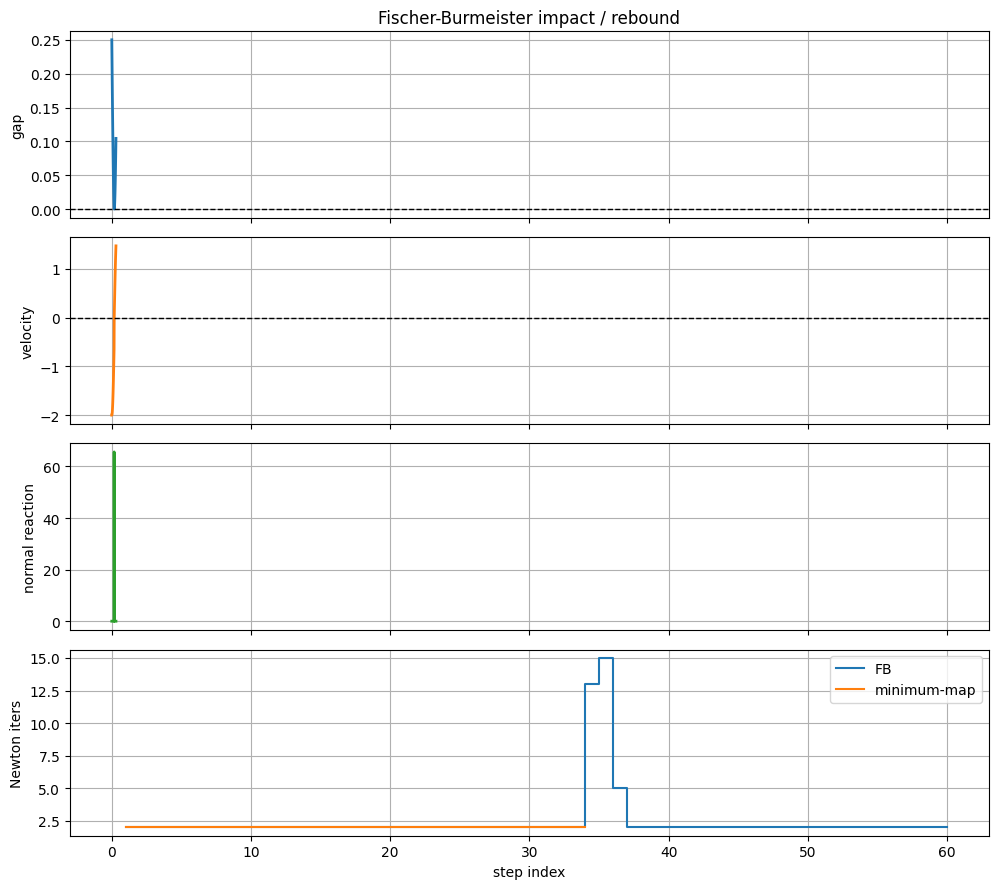

In [2]:
impact_fb_cs, impact_params = make_bouncing_mass_case("fischer_burmeister")
impact_mm_cs, _ = make_bouncing_mass_case("minimum_map")

impact_fb = run_case(impact_fb_cs, method="backward_euler", t_span=(0.0, 0.30), h=0.005, max_iter=80)
impact_mm = run_case(impact_mm_cs, method="backward_euler", t_span=(0.0, 0.30), h=0.005, max_iter=80)

rows = []
for label, cs, result in [
    ("minimum_map", impact_mm_cs, impact_mm),
    ("fischer_burmeister", impact_fb_cs, impact_fb),
]:
    stats = iteration_stats(result)
    rn = result["y"][:, cs.n_phys]
    rows.append((
        label,
        result["success_all"],
        int((rn > 1e-8).sum()),
        stats["max"],
        f"{stats['mean']:.2f}",
        f"{result['y'][-1, 1]:.4f}",
    ))

print_table(
    ["ncp_type", "all steps converged", "contact steps", "max Newton iters", "mean Newton iters", "final gap"],
    rows,
)

t = impact_fb["t"]
y = impact_fb["y"]
v = y[:, 0]
q = y[:, 1]
rn = y[:, impact_fb_cs.n_phys]

fig, axs = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
axs[0].plot(t, q, lw=2)
axs[0].axhline(0.0, color="k", ls="--", lw=1)
axs[0].set_ylabel("gap")
axs[0].set_title("Fischer-Burmeister impact / rebound")

axs[1].plot(t, v, lw=2, color="C1")
axs[1].axhline(0.0, color="k", ls="--", lw=1)
axs[1].set_ylabel("velocity")

axs[2].plot(t, rn, lw=2, color="C2")
axs[2].set_ylabel("normal reaction")

axs[3].step(np.arange(1, impact_fb["iterations"].size + 1), impact_fb["iterations"], where="post", lw=1.5, label="FB")
axs[3].step(np.arange(1, impact_mm["iterations"].size + 1), impact_mm["iterations"], where="post", lw=1.5, label="minimum-map")
axs[3].set_ylabel("Newton iters")
axs[3].set_xlabel("step index")
axs[3].legend()

plt.tight_layout()
plt.show()


## 2. Friction threshold and first slip transition

This case keeps a slider pressed into the floor with a vertical preload and drives it with a sinusoidal tangential force.

What to look for:

- While the slider sticks, `v_x` stays almost zero and the tangential reaction tracks the applied load.
- Sliding begins once `|r_t|` reaches the Coulomb limit `mu r_n`.
- For this parameter set the clearest picture is obtained with Backward Euler.

This section is best read as a clean stick-to-slip threshold demo rather than a long-time accuracy benchmark.

all steps converged: True
first slip time: 0.5350000000000004
max |r_t| / (mu r_n): 1.000000
iteration stats: {'max': 33, 'mean': 4.691666666666666, 'median': 2.0}


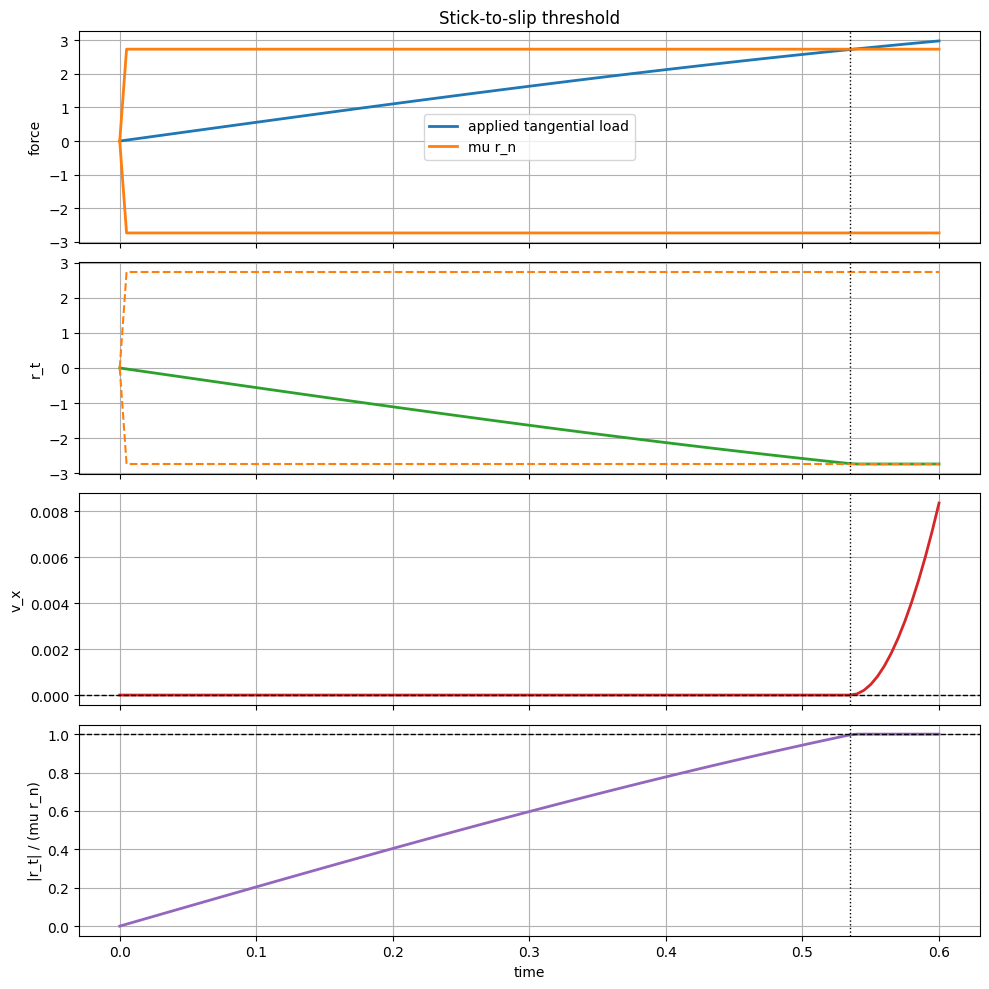

In [3]:
friction_cs, friction_params = make_friction_threshold_case("fischer_burmeister")
friction = run_case(friction_cs, method="backward_euler", t_span=(0.0, 0.60), h=0.005, max_iter=80)

t = friction["t"]
y = friction["y"]
phys = y[:, :friction_cs.n_phys]
react = y[:, friction_cs.n_phys:]

vx = phys[:, 0]
x = phys[:, 2]
gap = phys[:, 3]
rn = react[:, 0]
rt = react[:, 1]
drive = friction_params["F0"] * np.sin(friction_params["omega"] * t)
limit = friction_params["mu"] * np.maximum(rn, 0.0)
ratio = np.abs(rt) / np.maximum(limit, 1e-12)
slip = (rn > 1e-6) & ((np.abs(vx) >= 2e-3) | (ratio >= 0.995))
slip_idx = np.flatnonzero(slip)
first_slip_time = None if slip_idx.size == 0 else float(t[slip_idx[0]])

print(f"all steps converged: {friction['success_all']}")
print(f"first slip time: {first_slip_time}")
print(f"max |r_t| / (mu r_n): {ratio.max():.6f}")
print(f"iteration stats: {iteration_stats(friction)}")

fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axs[0].plot(t, drive, label="applied tangential load", lw=2)
axs[0].plot(t, limit, label="mu r_n", lw=2)
axs[0].plot(t, -limit, lw=2, color="C1")
axs[0].set_ylabel("force")
axs[0].legend()
axs[0].set_title("Stick-to-slip threshold")

axs[1].plot(t, rt, lw=2, color="C2", label="tangential reaction")
axs[1].plot(t, limit, lw=1.5, color="C1", ls="--")
axs[1].plot(t, -limit, lw=1.5, color="C1", ls="--")
axs[1].set_ylabel("r_t")

axs[2].plot(t, vx, lw=2, color="C3")
axs[2].axhline(0.0, color="k", ls="--", lw=1)
axs[2].set_ylabel("v_x")

axs[3].plot(t, ratio, lw=2, color="C4")
axs[3].axhline(1.0, color="k", ls="--", lw=1)
axs[3].set_ylabel("|r_t| / (mu r_n)")
axs[3].set_xlabel("time")

if slip_idx.size:
    for ax in axs:
        ax.axvline(first_slip_time, color="k", ls=":", lw=1)

plt.tight_layout()
plt.show()


## 3. Short-horizon integrator compatibility check

The last section is deliberately short-horizon.

It is meant to answer a narrow question: does the augmented NCP system run through the package's core implicit integrators on a contact-onset problem?

This is a compatibility sanity check, not a long-time accuracy comparison.

method         | all steps converged | contact steps | max Newton iters | mean Newton iters | final gap   | final r_n 
---------------+---------------------+---------------+------------------+-------------------+-------------+-----------
backward_euler |                   1 |             2 |               10 | 5.00              | 1.4091e-03  | 0.0000e+00
trapezoidal    |                   1 |             2 |               15 | 7.60              | 1.0435e-02  | 8.7084e-11
theta          |                   1 |             2 |               15 | 7.60              | 1.0435e-02  | 8.7084e-11
composite      |                   0 |             1 |               20 | 8.50              | -4.7376e-11 | 3.9212e+02
sdirk2         |                   1 |             1 |               22 | 9.60              | 3.4709e-03  | 0.0000e+00
embedded_betr  |                   1 |             2 |               15 | 7.60              | 1.0435e-02  | 8.7084e-11


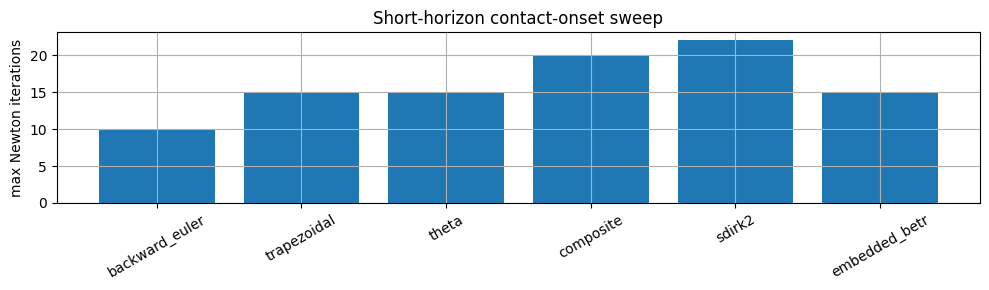

In [4]:
compat_cs, _ = make_bouncing_mass_case("fischer_burmeister", y0=np.array([-2.0, 0.05]))
methods = ["backward_euler", "trapezoidal", "theta", "composite", "sdirk2", "embedded_betr"]

rows = []
max_iters = []
for method in methods:
    result = run_case(compat_cs, method=method, t_span=(0.0, 0.05), h=0.01, max_iter=80)
    y = result["y"]
    rn = y[:, compat_cs.n_phys]
    stats = iteration_stats(result)
    rows.append((
        method,
        result["success_all"],
        int((rn > 1e-8).sum()),
        stats["max"],
        f"{stats['mean']:.2f}",
        f"{y[-1, 1]:.4e}",
        f"{rn[-1]:.4e}",
    ))
    max_iters.append(stats["max"])

print_table(
    ["method", "all steps converged", "contact steps", "max Newton iters", "mean Newton iters", "final gap", "final r_n"],
    rows,
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(methods, max_iters)
ax.set_ylabel("max Newton iterations")
ax.set_title("Short-horizon contact-onset sweep")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
